In [2]:
# cell 1
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB1

from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D,
    Dropout, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img, img_to_array, save_img
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.utils import class_weight

print("TensorFlow version:", tf.__version__)
print("All libraries imported!")

TensorFlow version: 2.19.0
All libraries imported!


In [9]:
# cell 2
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# CELL 4 - CONFIG


TARGET_PER_CLASS = 400   # was 300

# Update dataset path to your Google Drive mirror path
ORIGINAL_DATASET = "/content/drive/MyDrive/NutriLens/dataset/indian_food_dataset"
EXPANDED_DATASET = "/content/drive/MyDrive/NutriLens/dataset/indian_food_expanded"
MODEL_SAVE_PATH  = "/content/drive/MyDrive/NutriLens/saved_models/food_classifier.h5"
LABELS_SAVE_PATH = "/content/drive/MyDrive/NutriLens/saved_models/labels.json"

TARGET_PER_CLASS = 400
IMAGE_SIZE       = (224, 224)
BATCH_SIZE       = 32        # reduce to 16 if Colab runs out of memory
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 10     # phase 2 - fine tune top CNN layers

# create folders if they don't exist
os.makedirs(EXPANDED_DATASET, exist_ok=True)
os.makedirs("/content/drive/MyDrive/NutriLens/saved_models", exist_ok=True)

print("Config is ready!")
print(f"Original dataset : {ORIGINAL_DATASET}")
print(f"Expanded dataset : {EXPANDED_DATASET}")
print(f"Target per class : {TARGET_PER_CLASS} images")

Config is ready!
Original dataset : /content/drive/MyDrive/NutriLens/dataset/indian_food_dataset
Expanded dataset : /content/drive/MyDrive/NutriLens/dataset/indian_food_expanded
Target per class : 400 images


In [11]:
# CELL 5 - DATA AUGMENTATION
# Expands original dataset to TARGET_PER_CLASS images per class
# Uses heavy augmentation for small classes, standard for larger ones
# SAFE TO RE-RUN — skips if already done

print("=" * 70)
print("🎨 DATA AUGMENTATION")
print("=" * 70)
print(f"\n   Original : {ORIGINAL_DATASET}")
print(f"   Expanded : {EXPANDED_DATASET}")
print(f"   Target   : {TARGET_PER_CLASS} images per class\n")

# ── Check if already done ────────────────────────────────
class_folders_check = sorted([
    f for f in os.listdir(ORIGINAL_DATASET)
    if os.path.isdir(os.path.join(ORIGINAL_DATASET, f))
    and not f.startswith('.')
])

if len(class_folders_check) == 0:
    raise ValueError(f"❌ No class folders found in {ORIGINAL_DATASET}")

first_class    = class_folders_check[0]
expanded_first = os.path.join(EXPANDED_DATASET, first_class)
already_done   = (
    os.path.exists(expanded_first) and
    len(os.listdir(expanded_first)) >= TARGET_PER_CLASS
)

if already_done:
    print("✅ Augmentation already done — skipping.")
    print(f"   Expanded dataset at: {EXPANDED_DATASET}")
else:
    print("🚀 Starting augmentation...\n")

    # ── Augmentation generators ──────────────────────────
    # Standard — for classes with 200+ images
    aug_standard = ImageDataGenerator(
        rotation_range=30,
        zoom_range=0.25,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        brightness_range=[0.65, 1.35],
        channel_shift_range=15.0,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Heavy — for classes with fewer than 200 images
    aug_heavy = ImageDataGenerator(
        rotation_range=45,
        zoom_range=0.35,
        width_shift_range=0.25,
        height_shift_range=0.25,
        shear_range=0.25,
        brightness_range=[0.5, 1.5],
        channel_shift_range=25.0,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    class_folders = sorted([
        f for f in os.listdir(ORIGINAL_DATASET)
        if os.path.isdir(os.path.join(ORIGINAL_DATASET, f))
        and not f.startswith('.')
    ])
    print(f"📂 Found {len(class_folders)} classes\n")

    # ── Process each class ───────────────────────────────
    for class_name in class_folders:
        src_folder = os.path.join(ORIGINAL_DATASET, class_name)
        dst_folder = os.path.join(EXPANDED_DATASET, class_name)
        os.makedirs(dst_folder, exist_ok=True)

        image_files = [
            f for f in os.listdir(src_folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            and not f.startswith('.')
        ]
        original_count = len(image_files)

        if original_count == 0:
            print(f"  ⚠️  {class_name:<25} — no images found, skipping")
            continue

        aug        = aug_heavy if original_count < 200 else aug_standard
        strength   = "HEAVY" if original_count < 200 else "standard"

        print(f"  {class_name:<25} {original_count:>3} imgs  "
              f"({strength})", end=" → ")

        # Step 1: Copy originals
        original_arrays = []
        img_count = 0

        for img_file in image_files:
            src_path = os.path.join(src_folder, img_file)
            dst_path = os.path.join(dst_folder, img_file)
            try:
                img = load_img(src_path, target_size=IMAGE_SIZE)
                arr = img_to_array(img)
                save_img(dst_path, arr)
                original_arrays.append(arr)
                img_count += 1
            except Exception as e:
                print(f"\n    ⚠️  Skipping {img_file}: {e}")
                continue

        if len(original_arrays) == 0:
            print("❌ No valid images loaded — skipping")
            continue

        # Step 2: Generate augmented images until TARGET_PER_CLASS
        aug_count = 0
        while img_count < TARGET_PER_CLASS:
            try:
                base = original_arrays[aug_count % len(original_arrays)]
                base = base.reshape((1,) + base.shape)

                for aug_img in aug.flow(base, batch_size=1):
                    save_name = f"aug_{aug_count:04d}.jpg"
                    save_path = os.path.join(dst_folder, save_name)
                    save_img(save_path, aug_img[0])
                    aug_count += 1
                    img_count += 1
                    break

            except Exception as e:
                print(f"\n    ⚠️  Augmentation error: {e}")
                break

        print(f"{img_count:>4} total  ({aug_count:>3} generated)")

    # ── Summary ──────────────────────────────────────────
    print("\n" + "=" * 70)
    print("✅ AUGMENTATION COMPLETE!")
    print("=" * 70)

    final_classes = [
        f for f in os.listdir(EXPANDED_DATASET)
        if not f.startswith('.')
    ]
    total_expanded = sum(
        len([
            f for f in os.listdir(os.path.join(EXPANDED_DATASET, c))
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        for c in final_classes
    )
    print(f"\n   Classes processed : {len(final_classes)}")
    print(f"   Total images      : {total_expanded}")
    print(f"   Avg per class     : {total_expanded // max(len(final_classes), 1)}")
    print(f"\n✅ Ready — run Cell 6 to verify")

🎨 DATA AUGMENTATION

   Original : /content/drive/MyDrive/NutriLens/dataset/indian_food_dataset
   Expanded : /content/drive/MyDrive/NutriLens/dataset/indian_food_expanded
   Target   : 400 images per class

🚀 Starting augmentation...

📂 Found 22 classes

  biryani                   147 imgs  (HEAVY) →  400 total  (253 generated)
  chai                      381 imgs  (standard) →  400 total  ( 19 generated)
  chole_bhature             411 imgs  (standard) →  411 total  (  0 generated)
  dhokla                    289 imgs  (standard) →  400 total  (111 generated)
  dosa                      311 imgs  (standard) →  400 total  ( 89 generated)
  gulab_jamun               170 imgs  (HEAVY) → 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


 400 total  (230 generated)
  idli                      309 imgs  (standard) →  400 total  ( 91 generated)
  jalebi                    297 imgs  (standard) →  400 total  (103 generated)
  kulfi                     236 imgs  (standard) →  400 total  (164 generated)
  medu_wada                 176 imgs  (HEAVY) →  400 total  (224 generated)
  momos                     319 imgs  (standard) →  400 total  ( 81 generated)
  naan                      329 imgs  (standard) →  400 total  ( 71 generated)
  pakode                    278 imgs  (standard) →  400 total  (122 generated)
  paneer                    336 imgs  (standard) →  400 total  ( 64 generated)
  pani_puri                 169 imgs  (HEAVY) →  400 total  (231 generated)
  pav_bhaji                 353 imgs  (standard) →  400 total  ( 47 generated)
  poha                      222 imgs  (standard) →  400 total  (178 generated)
  rajma_chawal              305 imgs  (standard) →  400 total  ( 95 generated)
  roll                      29

In [12]:
# CELL 6 - VERIFY AUGMENTED DATASET
print("=" * 60)
print("Verifying expanded dataset...")
print("=" * 60)

class_folders = sorted([
    f for f in os.listdir(EXPANDED_DATASET)
    if os.path.isdir(os.path.join(EXPANDED_DATASET, f))
    and not f.startswith('.')
])

all_good = True
total_images = 0
for class_name in class_folders:
    path  = os.path.join(EXPANDED_DATASET, class_name)
    count = len([f for f in os.listdir(path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    total_images += count
    status = "✅ OK" if count >= TARGET_PER_CLASS else "⚠️  CHECK!"
    if "CHECK" in status:
        all_good = False
    print(f"  {class_name:<25} {count:>4}  {status}")

print(f"\n{'─'*60}")
print(f"  Total classes  : {len(class_folders)}")
print(f"  Total images   : {total_images}")
print(f"  Avg per class  : {total_images // max(len(class_folders),1)}")
print(f"  All good       : {all_good}")
print("=" * 60)

Verifying expanded dataset...
  biryani                    400  ✅ OK
  chai                       400  ✅ OK
  chole_bhature              411  ✅ OK
  dhokla                     400  ✅ OK
  dosa                       400  ✅ OK
  gulab_jamun                400  ✅ OK
  idli                       400  ✅ OK
  jalebi                     400  ✅ OK
  kulfi                      400  ✅ OK
  medu_wada                  400  ✅ OK
  momos                      400  ✅ OK
  naan                       400  ✅ OK
  pakode                     400  ✅ OK
  paneer                     400  ✅ OK
  pani_puri                  400  ✅ OK
  pav_bhaji                  400  ✅ OK
  poha                       400  ✅ OK
  rajma_chawal               400  ✅ OK
  roll                       400  ✅ OK
  roti                       413  ✅ OK
  samosa                     400  ✅ OK
  vada_pav                   400  ✅ OK

────────────────────────────────────────────────────────────
  Total classes  : 22
  Total images   : 8824
  Av

In [13]:
# CELL 6A - CREATE CLEAN VALIDATION SPLIT
# Splits original images 80/20 BEFORE training
# Val images are removed from expanded dataset to prevent leakage
# RUN ONCE — checks if already done before proceeding
# -------------------------------------------------------
import shutil
import random

VAL_DATASET = "/content/drive/MyDrive/NutriLens/dataset/indian_food_val"
SPLIT_RATIO = 0.2   # 20% of originals go to val
SEED        = 42
random.seed(SEED)

# Check if already done
if os.path.exists(VAL_DATASET) and len(os.listdir(VAL_DATASET)) > 0:
    print("✅ Val split already exists — skipping.")
    val_classes = [f for f in os.listdir(VAL_DATASET) if not f.startswith('.')]
    total_val   = sum(
        len(os.listdir(os.path.join(VAL_DATASET, c)))
        for c in val_classes
    )
    print(f"   {len(val_classes)} classes, {total_val} total val images")
else:
    print("=" * 60)
    print("Creating clean train/val split from original dataset...")
    print("=" * 60)

    class_folders = sorted([
        f for f in os.listdir(ORIGINAL_DATASET)
        if os.path.isdir(os.path.join(ORIGINAL_DATASET, f))
        and not f.startswith('.')
    ])

    total_moved  = 0
    total_removed = 0

    for class_name in class_folders:
        src_dir = os.path.join(ORIGINAL_DATASET, class_name)
        val_dir = os.path.join(VAL_DATASET, class_name)
        os.makedirs(val_dir, exist_ok=True)

        # Get all original images
        all_images = sorted([
            f for f in os.listdir(src_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            and not f.startswith('.')
        ])

        # Shuffle and split
        random.shuffle(all_images)
        n_val   = max(1, int(len(all_images) * SPLIT_RATIO))
        val_imgs = all_images[:n_val]

        moved   = 0
        removed = 0

        for img_file in val_imgs:
            src_path = os.path.join(src_dir, img_file)
            val_path = os.path.join(val_dir, img_file)

            # 1. Copy original image to val folder
            shutil.copy2(src_path, val_path)
            moved += 1

            # 2. Remove its augmented counterpart from EXPANDED_DATASET
            # Original images were copied as-is (same filename) during augmentation
            exp_path = os.path.join(EXPANDED_DATASET, class_name, img_file)
            if os.path.exists(exp_path):
                os.remove(exp_path)
                removed += 1

        total_moved   += moved
        total_removed += removed
        remaining = len([
            f for f in os.listdir(os.path.join(EXPANDED_DATASET, class_name))
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        print(f"  {class_name:<25} val={moved:>3}  "
              f"leaks_removed={removed:>3}  train_remaining={remaining:>4}")

    print(f"\n{'─'*60}")
    print(f"✅ Split complete!")
    print(f"   Val images created      : {total_moved}")
    print(f"   Leaking images removed  : {total_removed}")
    print(f"   Val dataset at          : {VAL_DATASET}")
    print(f"\n⚠️  Update VAL_DATASET variable in Cell 7!")

Creating clean train/val split from original dataset...
  biryani                   val= 29  leaks_removed= 29  train_remaining= 371
  chai                      val= 76  leaks_removed= 76  train_remaining= 324
  chole_bhature             val= 82  leaks_removed= 82  train_remaining= 329
  dhokla                    val= 57  leaks_removed= 57  train_remaining= 343
  dosa                      val= 62  leaks_removed= 62  train_remaining= 338
  gulab_jamun               val= 34  leaks_removed= 34  train_remaining= 366
  idli                      val= 61  leaks_removed= 61  train_remaining= 339
  jalebi                    val= 59  leaks_removed= 59  train_remaining= 341
  kulfi                     val= 47  leaks_removed= 47  train_remaining= 353
  medu_wada                 val= 35  leaks_removed= 35  train_remaining= 365
  momos                     val= 63  leaks_removed= 63  train_remaining= 337
  naan                      val= 65  leaks_removed= 65  train_remaining= 335
  pakode            

In [14]:
# CELL 7 - DATA GENERATORS

from tensorflow.keras.applications.efficientnet import preprocess_input

# ⚠️ Make sure this matches Cell 3
VAL_DATASET = "/content/drive/MyDrive/NutriLens/dataset/indian_food_val"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    EXPANDED_DATASET,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    VAL_DATASET,          # ✅ must point to VAL_DATASET not ORIGINAL_DATASET
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
print(f"✅ Classes found     : {num_classes}")
print(f"✅ Training images   : {train_generator.samples}")
print(f"✅ Validation images : {val_generator.samples}")

Found 7599 images belonging to 22 classes.
Found 1225 images belonging to 22 classes.
✅ Classes found     : 22
✅ Training images   : 7599
✅ Validation images : 1225


In [15]:
# CELL 8 - SAVE CLASS LABELS
labels          = train_generator.class_indices          # {'biryani': 0, ...}
labels_reversed = {v: k for k, v in labels.items()}     # {0: 'biryani', ...}

with open(LABELS_SAVE_PATH, 'w') as f:
    json.dump(labels_reversed, f, indent=4)

print("✅ Labels saved to:", LABELS_SAVE_PATH)
print(f"   {len(labels_reversed)} classes: {list(labels_reversed.values())}")

✅ Labels saved to: /content/drive/MyDrive/NutriLens/saved_models/labels.json
   22 classes: ['biryani', 'chai', 'chole_bhature', 'dhokla', 'dosa', 'gulab_jamun', 'idli', 'jalebi', 'kulfi', 'medu_wada', 'momos', 'naan', 'pakode', 'paneer', 'pani_puri', 'pav_bhaji', 'poha', 'rajma_chawal', 'roll', 'roti', 'samosa', 'vada_pav']


In [16]:
# CELL 9 - CLASS WEIGHTS
# Helps model handle slight imbalance (biryani=147 raw vs roti=413 raw)
# Even after augmentation to 400, val set still reflects real imbalance

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights_array))

print("✅ Class weights computed!")
for idx, w in class_weights_dict.items():
    name = labels_reversed.get(idx, str(idx))
    print(f"   {name:<25} weight = {w:.4f}")

✅ Class weights computed!
   biryani                   weight = 0.9310
   chai                      weight = 1.0661
   chole_bhature             weight = 1.0499
   dhokla                    weight = 1.0070
   dosa                      weight = 1.0219
   gulab_jamun               weight = 0.9437
   idli                      weight = 1.0189
   jalebi                    weight = 1.0129
   kulfi                     weight = 0.9785
   medu_wada                 weight = 0.9463
   momos                     weight = 1.0250
   naan                      weight = 1.0311
   pakode                    weight = 1.0012
   paneer                    weight = 1.0373
   pani_puri                 weight = 0.9412
   pav_bhaji                 weight = 1.0467
   poha                      weight = 0.9703
   rajma_chawal              weight = 1.0189
   roll                      weight = 1.0100
   roti                      weight = 1.0435
   samosa                    weight = 0.9926
   vada_pav                  

In [17]:
# CELL 10 - BUILD MODEL
# EfficientNetB1 (slight upgrade from B0) — better for 22 diverse classes
# Stronger regularization to fight overfitting on 400-image classes

from tensorflow.keras.applications import EfficientNetB1

base_model = EfficientNetB1(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False
print(f"✅ EfficientNetB1 loaded — {len(base_model.layers)} layers")

x = base_model.output
x = GlobalAveragePooling2D()(x)

# Head with stronger regularization vs before
x = BatchNormalization()(x)
x = Dense(512, activation='relu',
          kernel_regularizer=regularizers.l2(0.005))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.005))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

outputs = Dense(num_classes, activation='softmax')(x)
model   = Model(inputs=base_model.input, outputs=outputs)

total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"✅ Model built!")
print(f"   Total params     : {total_params:,}")
print(f"   Trainable params : {trainable_params:,}")

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB1 loaded — 340 layers
✅ Model built!
   Total params     : 7,376,285
   Trainable params : 796,950


In [18]:
# CELL 11 - CALLBACKS
# patience increased slightly since dataset is larger and more stable

def get_callbacks(phase=1):
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=7,                    # was 6 — give more room with bigger data
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=f'/content/drive/MyDrive/NutriLens/best_model_phase{phase}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
    return [early_stop, reduce_lr, checkpoint]

print("✅ Callbacks ready (EarlyStopping | ReduceLR | ModelCheckpoint)")

✅ Callbacks ready (EarlyStopping | ReduceLR | ModelCheckpoint)


In [19]:
# SANITY CHECK CELL
print("Checking setup...\n")

try:
    from tensorflow.keras.applications.efficientnet import preprocess_input
    print("CHECK 1: preprocess_input import        ✅ OK")
except:
    print("CHECK 1: preprocess_input import        ❌ FAILED")

fn = train_generator.image_data_generator.preprocessing_function
print(f"CHECK 2: preprocessing_function set      {'✅ OK' if fn else '❌ FAILED — fix Cell 7'}")

bs = train_generator.batch_size
print(f"CHECK 3: Batch size = {bs}              {'✅ OK' if bs == 32 else '⚠️  Expected 32'}")

nc = train_generator.num_classes
print(f"CHECK 4: Classes found = {nc}           {'✅ OK' if nc == 22 else f'⚠️  Expected 22, got {nc}'}")

ns = train_generator.samples
print(f"CHECK 5: Training images = {ns}        {'✅ OK' if ns >= 7000 else '⚠️  Seems low'}")

nv = val_generator.samples
print(f"CHECK 6: Validation images = {nv}      {'✅ OK' if nv > 1000 else '⚠️  Seems low'}")

Checking setup...

CHECK 1: preprocess_input import        ✅ OK
CHECK 2: preprocessing_function set      ✅ OK
CHECK 3: Batch size = 32              ✅ OK
CHECK 4: Classes found = 22           ✅ OK
CHECK 5: Training images = 7599        ✅ OK
CHECK 6: Validation images = 1225      ✅ OK


In [20]:
# CELL 12 - PHASE 1: Train classifier head only
# EfficientNetB1 frozen — only our Dense layers learn
# Higher LR is fine here since base is frozen

print("=" * 55)
print("PHASE 1 — Classifier head training (base frozen)")
print("=" * 55)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=get_callbacks(phase=1),
    class_weight=class_weights_dict,
    verbose=1
)

phase1_best = max(history1.history['val_accuracy']) * 100
train_best  = max(history1.history['accuracy']) * 100
gap         = train_best - phase1_best
print(f"\n✅ Phase 1 complete!")
print(f"   Best val accuracy   : {phase1_best:.2f}%")
print(f"   Best train accuracy : {train_best:.2f}%")
print(f"   Train-val gap       : {gap:.2f}%  {'(good)' if gap < 10 else '(some overfit — normal)'}")

PHASE 1 — Classifier head training (base frozen)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.4140 - loss: 7.4351
Epoch 1: val_accuracy improved from -inf to 0.81224, saving model to /content/drive/MyDrive/NutriLens/best_model_phase1.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 258s 880ms/step - accuracy: 0.4146 - loss: 7.4309 - val_accuracy: 0.8122 - val_loss: 4.8947 - learning_rate: 0.0010
Epoch 2/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.7256 - loss: 4.7660
Epoch 2: val_accuracy improved from 0.81224 to 0.83429, saving model to /content/drive/MyDrive/NutriLens/best_model_phase1.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 177s 658ms/step - accuracy: 0.7256 - loss: 4.7646 - val_accuracy: 0.8343 - val_loss: 3.5595 - learning_rate: 0.0010
Epoch 3/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.7821 - loss: 3.4486
Epoch 3: val_accuracy improved from 0.83429 to 0.84816, saving model to /content/drive/MyDrive/NutriLens/best_model_phase1.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 156s 654ms/step - accuracy: 0.782

In [21]:
# CELL 13 - PHASE 2: Fine-tune top EfficientNetB1 layers
# Unfreeze last 30 layers — learns Indian food-specific features
# Much lower LR to avoid destroying ImageNet weights

print("=" * 55)
print("PHASE 2 — Fine-tuning top EfficientNet layers")
print("=" * 55)

base_model.trainable = True

# Freeze all except last 30 layers
UNFREEZE_LAYERS = 30
for layer in base_model.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

# Keep BatchNorm frozen to preserve ImageNet statistics
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"✅ Unfrozen {UNFREEZE_LAYERS} EfficientNet layers for fine-tuning")
print(f"   Total trainable layers in model: {trainable_count}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),   # lower than before
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE2,
    callbacks=get_callbacks(phase=2),
    class_weight=class_weights_dict,
    verbose=1
)

phase2_best = max(history2.history['val_accuracy']) * 100
train_best2 = max(history2.history['accuracy']) * 100
gap2        = train_best2 - phase2_best
print(f"\n✅ Phase 2 complete!")
print(f"   Best val accuracy   : {phase2_best:.2f}%")
print(f"   Best train accuracy : {train_best2:.2f}%")
print(f"   Train-val gap       : {gap2:.2f}%")
print(f"\n🏆 Overall best val accuracy: {max(phase1_best, phase2_best):.2f}%")

PHASE 2 — Fine-tuning top EfficientNet layers
✅ Unfrozen 30 EfficientNet layers for fine-tuning
   Total trainable layers in model: 32
Epoch 1/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.8777 - loss: 1.3324
Epoch 1: val_accuracy improved from -inf to 0.88408, saving model to /content/drive/MyDrive/NutriLens/best_model_phase2.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 247s 843ms/step - accuracy: 0.8777 - loss: 1.3323 - val_accuracy: 0.8841 - val_loss: 1.3017 - learning_rate: 5.0000e-05
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.8918 - loss: 1.2265
Epoch 2: val_accuracy improved from 0.88408 to 0.89061, saving model to /content/drive/MyDrive/NutriLens/best_model_phase2.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 161s 675ms/step - accuracy: 0.8918 - loss: 1.2263 - val_accuracy: 0.8906 - val_loss: 1.2431 - learning_rate: 5.0000e-05
Epoch 3/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9133 - loss: 1.1275
Epoch 3: val_accuracy improved from 0.89061 to 0

In [32]:
# CELL 14 - SAVE MODEL
# -------------------------------------------------------
model.save(MODEL_SAVE_PATH)
print(f"Model saved at: {MODEL_SAVE_PATH}")

Model saved at: /content/drive/MyDrive/NutriLens/saved_models/food_classifier.h5


In [ ]:
# CELL 15 - PLOT TRAINING RESULTS
# Shows accuracy and loss for both phases combined
# Grey dotted line = where phase 1 ended, phase 2 started
# -------------------------------------------------------
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']

phase1_end   = len(history1.history['accuracy'])
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc,     label='Train Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Val Accuracy',   color='orange')
plt.axvline(x=phase1_end - 1, color='gray',
            linestyle='--', label='Phase 1 → Phase 2')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss,     label='Train Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Val Loss',   color='orange')
plt.axvline(x=phase1_end - 1, color='gray',
            linestyle='--', label='Phase 1 → Phase 2')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NutriLens/training_results.png")
plt.show()

print(f"\nPhase 1 best val accuracy : {phase1_best:.2f}%")
print(f"Phase 2 best val accuracy : {phase2_best:.2f}%")
print(f"Overall best val accuracy : {max(val_acc)*100:.2f}%")

In [22]:
# CELL 16 - TEST ON A SINGLE IMAGE
#
# Upload any food photo to Colab and test the model
# To upload: click folder icon on left panel → upload
# Then change the path below to your image filename
# -------------------------------------------------------
def predict_food(img_path):
    """
    Tests the model on one image.
    Shows image with predicted food name and confidence score.
    """
    img       = load_img(img_path, target_size=IMAGE_SIZE)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions     = model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    confidence      = predictions[0][predicted_index] * 100
    predicted_food  = labels_reversed[predicted_index]

    # show top 3 predictions - useful for debugging
    top3_indices = np.argsort(predictions[0])[::-1][:3]
    print("Top 3 predictions:")
    for idx in top3_indices:
        food = labels_reversed[idx]
        conf = predictions[0][idx] * 100
        print(f"  {food:<25} {conf:.1f}%")

    # show image
    plt.figure(figsize=(5, 5))
    plt.imshow(load_img(img_path))
    plt.title(f"Predicted : {predicted_food}\n"
              f"Confidence: {confidence:.1f}%", fontsize=13)
    plt.axis('off')
    plt.show()

    return predicted_food, confidence

In [28]:
# CELL 16 - TEST ON A SINGLE IMAGE
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_food(img_path):
    img       = load_img(img_path, target_size=IMAGE_SIZE)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)          # ✅ same as training
    img_array = np.expand_dims(img_array, axis=0)

    predictions     = model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    confidence      = predictions[0][predicted_index] * 100
    predicted_food  = labels_reversed[predicted_index]

    # show top 3 predictions
    top3_indices = np.argsort(predictions[0])[::-1][:3]
    print("Top 3 predictions:")
    for idx in top3_indices:
        food = labels_reversed[idx]
        conf = predictions[0][idx] * 100
        print(f"  {food:<25} {conf:.1f}%")

    # show image
    plt.figure(figsize=(5, 5))
    plt.imshow(load_img(img_path))
    plt.title(f"Predicted : {predicted_food}\nConfidence: {confidence:.1f}%", fontsize=13)
    plt.axis('off')
    plt.show()

    return predicted_food, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Top 3 predictions:
  momos                     99.4%
  naan                      0.3%
  samosa                    0.1%


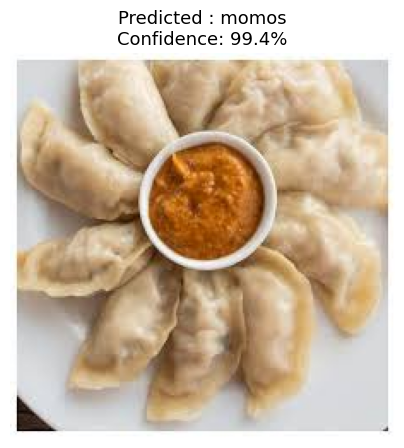


Final Prediction: momos
Model Confidence: 99.45%


In [35]:
image_path = "/content/download.jpg"

predicted_food, confidence = predict_food(image_path)

print(f"\nFinal Prediction: {predicted_food}")
print(f"Model Confidence: {confidence:.2f}%")

In [27]:
import numpy as np

# Check what the model predicts on a batch
batch_images, batch_labels = next(iter(val_generator))
predictions = model.predict(batch_images)
predicted_classes = np.argmax(predictions, axis=1)

print("Predicted class distribution (should be varied):")
from collections import Counter
counts = Counter(predicted_classes.tolist())
for class_idx, count in sorted(counts.items()):
    print(f"  Class {class_idx} ({labels_reversed[class_idx]}): {count} times")

print("\nTrue class distribution:")
true_classes = np.argmax(batch_labels, axis=1)
for class_idx, count in Counter(true_classes.tolist()).items():
    print(f"  Class {class_idx} ({labels_reversed[class_idx]}): {count} times")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Predicted class distribution (should be varied):
  Class 0 (biryani): 26 times
  Class 1 (chai): 3 times
  Class 15 (pav_bhaji): 1 times
  Class 16 (poha): 2 times

True class distribution:
  Class 0 (biryani): 29 times
  Class 1 (chai): 3 times
